# 🎮 Hutch Games Analytics Project
## Notebook 03 — Player Segmentation & ML Clustering

**Analyst:** Ebi Mologe  
**Dataset:** `players.csv` + `segments_truth.csv` + `daily_activity.csv`  
**Objective:** Build behavioural segments from player activity data using unsupervised clustering,  
then compare them against business-defined segments (Casual, Grinder-F2W, Spender, Whale, Churned-early).  

This notebook showcases **ML skills directly relevant to a Games Analyst role**: feature engineering,  
scaling, clustering, and confusion-matrix-style evaluation of discovered segments vs ground-truth labels.

---
### Business Questions
> 1. Can we rediscover whales / spenders / grinders purely from behavioural telemetry?  
> 2. How cleanly do unsupervised clusters align with the studio's existing player segments?  
> 3. Which behavioural features most distinguish high-value players from casual / churned users?

## 1. Setup & Imports

In [ ]:
%pip install scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

DATA_DIR = Path('/Users/ebimol/GamesAnalyticsProject')
OUT_DIR  = DATA_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi']     = 150
plt.rcParams['figure.figsize'] = (12, 5)
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
sns.set_theme(style='whitegrid', palette=PALETTE)

print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Data

In [2]:
players = pd.read_csv(DATA_DIR / 'players.csv',
                      parse_dates=['install_date','last_active_date'])
segments_truth = pd.read_csv(DATA_DIR / 'segments_truth.csv')
daily   = pd.read_csv(DATA_DIR / 'daily_activity.csv', parse_dates=['date'])

print(f'players shape        : {players.shape}')
print(f'segments_truth shape: {segments_truth.shape}')
print(f'daily shape          : {daily.shape}')

print('\n=== segments_truth sample ===')
display(segments_truth.head())
print('\nSegment distribution:')
print(segments_truth['true_segment'].value_counts())

players shape        : (30000, 22)
segments_truth shape: (30000, 2)
daily shape          : (208310, 12)

=== segments_truth sample ===


,player_id,true_segment
0,P0000001,Churned-early
1,P0000002,Casual
2,P0000003,Casual
3,P0000004,Casual
4,P0000005,Casual



Segment distribution:
true_segment
Casual           13528
Churned-early    10635
Grinder-F2W       4832
Spender            867
Whale              138
Name: count, dtype: int64


## 3. Merge Player Table with Ground-Truth Segments

In [3]:
df = players.merge(segments_truth, on='player_id', how='left')

assert df['true_segment'].notnull().all(), 'Missing true_segment labels after merge!'
print('All players have ground-truth segments ✓')

print('\nTrue segment distribution:')
print(df['true_segment'].value_counts())

display(df[['player_id','true_segment',
            'total_sessions','total_playtime_min','total_iap_usd']].head())

All players have ground-truth segments ✓

True segment distribution:
true_segment
Casual           13528
Churned-early    10635
Grinder-F2W       4832
Spender            867
Whale              138
Name: count, dtype: int64


,player_id,true_segment,total_sessions,total_playtime_min,total_iap_usd
0,P0000001,Churned-early,3,9.75,0.0
1,P0000002,Casual,21,92.48,0.0
2,P0000003,Casual,25,158.61,0.0
3,P0000004,Casual,14,74.37,0.0
4,P0000005,Casual,24,103.27,0.0


## 4. Feature Engineering for Clustering

We construct behavioural features that should intuitively distinguish:
- **Whales / Spenders** — high IAP, high currency/gems spend, many characters, longer playtime.  
- **Grinders-F2W** — high sessions and playtime, high currency spend, but very low/no IAP.  
- **Casual / Churned-early** — few sessions, low playtime, low spend, low character count.

To keep the clustering robust and interpretable, we avoid leak-prone features like `true_segment`  
or labels tied directly to monetization rules, and instead rely on raw behavioural telemetry.

Feature summary:


,count,mean,std,min,25%,50%,75%,max
days_active,30000.0,6.94,7.92,1.0,1.00,4.00,9.00,87.00
total_sessions,30000.0,29.15,48.41,1.0,3.00,12.00,27.00,833.00
total_playtime_min,30000.0,229.55,439.34,2.0,14.43,69.24,170.85,8414.25
win_rate,30000.0,0.43,0.22,0.0,0.29,0.44,0.58,1.00
currency_spent_total,30000.0,1909.31,5091.11,0.0,139.00,546.00,1327.00,283840.00
gems_spent_total,30000.0,693.56,4883.50,0.0,0.00,2.00,300.00,407205.00
characters_owned,30000.0,4.21,4.32,3.0,3.00,3.00,3.00,95.00
promoted_characters,30000.0,0.04,0.62,0.0,0.00,0.00,0.00,43.00
legendary_count,30000.0,0.06,0.46,0.0,0.00,0.00,0.00,33.00
total_iap_usd,30000.0,3.52,55.68,0.0,0.00,0.00,0.00,5227.75



Correlation heatmap (quick visual sanity check):


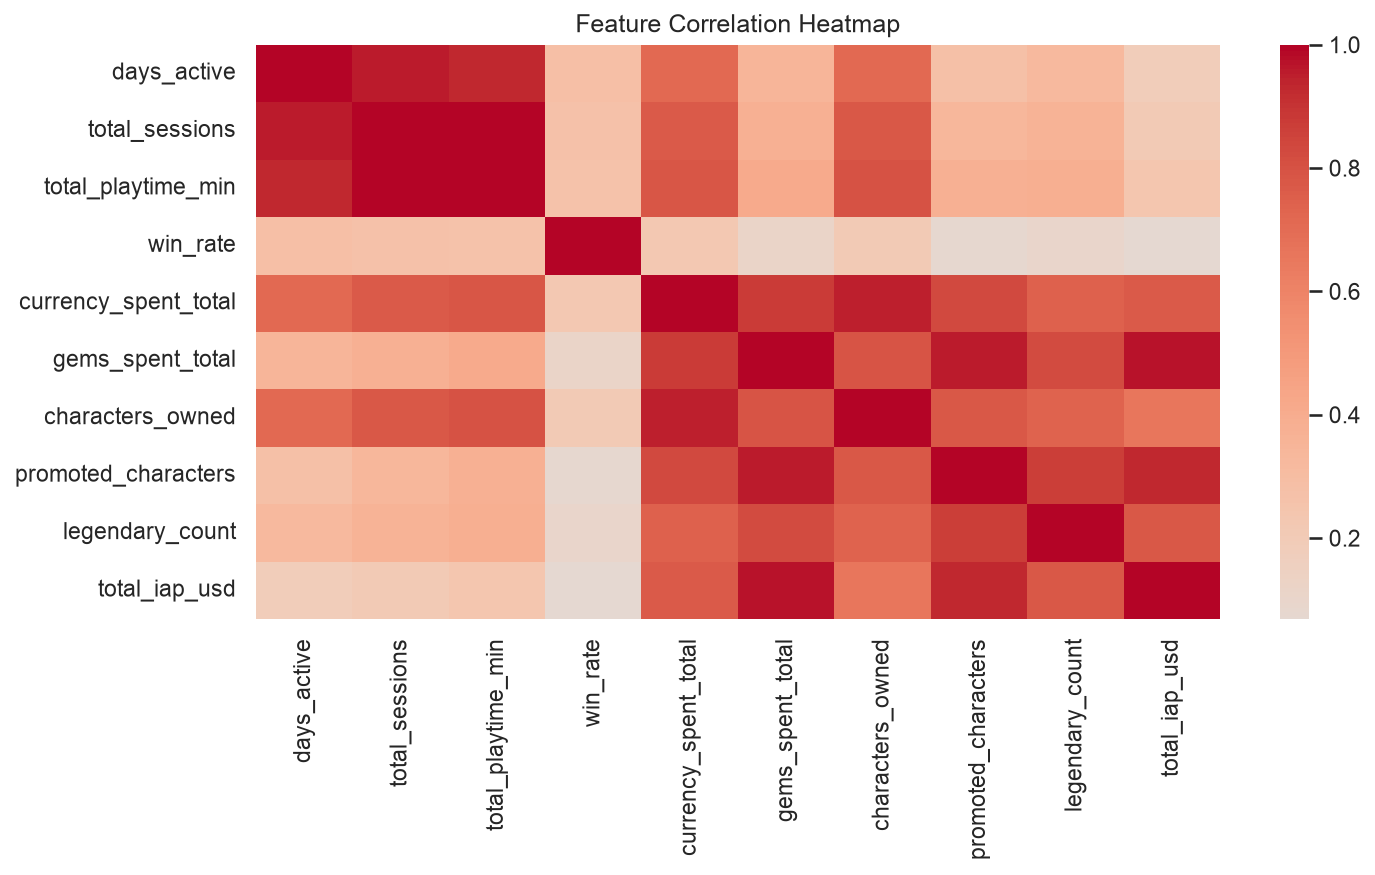

Chart saved ✓


In [4]:
feature_cols = [
    'days_active',
    'total_sessions',
    'total_playtime_min',
    'win_rate',
    'currency_spent_total',
    'gems_spent_total',
    'characters_owned',
    'promoted_characters',
    'legendary_count',
    'total_iap_usd',
]

X = df[feature_cols].copy()

print('Feature summary:')
display(X.describe().T.round(2))

print('\nCorrelation heatmap (quick visual sanity check):')
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUT_DIR / '03_feature_corr.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 5. Scaling & KMeans Clustering

We cluster players into 5 behavioural segments (matching the 5 ground-truth labels) using:
- **Features:** sessions, playtime, win rate, currency/gems spend, characters, IAP.
- **Scaling:** `StandardScaler` to put all features on comparable scales.
- **Algorithm:** KMeans with k=5 and a fixed random seed for reproducibility.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df[[
    'days_active',
    'total_sessions',
    'total_playtime_min',
    'win_rate',
    'currency_spent_total',
    'gems_spent_total',
    'characters_owned',
    'promoted_characters',
    'legendary_count',
    'total_iap_usd',
]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster_k5'] = kmeans.fit_predict(X_scaled)

print('Cluster sizes (k=5):')
print(df['cluster_k5'].value_counts().sort_index())

Cluster sizes (k=5):
cluster_k5
0    14516
1       76
2     3472
3    11933
4        3
Name: count, dtype: int64


## 6. Cluster Profiling — Behavioural Means

We profile each cluster by averaging key behavioural features, which lets us interpret
clusters in plain language (e.g., **High-IAP Whales**, **F2P Grinders**, **Casuals**).

In [6]:
feature_cols = [
    'days_active',
    'total_sessions',
    'total_playtime_min',
    'win_rate',
    'currency_spent_total',
    'gems_spent_total',
    'characters_owned',
    'promoted_characters',
    'legendary_count',
    'total_iap_usd',
]

cluster_profile = df.groupby('cluster_k5')[feature_cols].mean().round(2)

print('Cluster feature means:')
display(cluster_profile)

Cluster feature means:


,days_active,total_sessions,total_playtime_min,win_rate,currency_spent_total,gems_spent_total,characters_owned,promoted_characters,legendary_count,total_iap_usd
cluster_k5,,,,,,,,,,
0,5.61,18.79,132.71,0.57,1043.49,241.25,3.37,0.00,0.02,0.43
1,42.04,311.09,3209.79,0.70,59551.07,55852.29,62.76,7.99,5.21,572.34
2,24.30,136.20,1182.74,0.57,9328.33,3220.58,10.39,0.18,0.27,12.52
3,3.28,8.79,50.65,0.22,380.60,75.32,3.04,0.00,0.01,0.02
4,22.33,165.00,1741.89,0.66,225516.67,326528.00,95.00,37.67,22.00,3980.92


## 7. Cluster vs True Segment (Confusion Matrix)

We compare discovered clusters vs the studio's ground-truth segments using a
confusion-matrix-style cross-tab. This shows how well clustering recovers
Casual / Grinder-F2W / Spender / Whale / Churned-early labels.

In [7]:
ct = pd.crosstab(df['true_segment'], df['cluster_k5'])
ct_norm = ct.div(ct.sum(axis=1), axis=0).round(3)

print('Raw counts:')
display(ct)
print('\nRow-normalised (within true_segment):')
display(ct_norm)

Raw counts:


cluster_k5,0,1,2,3,4
true_segment,,,,,
Casual,8269,0,0,5259,0
Churned-early,4024,0,0,6611,0
Grinder-F2W,2059,0,2710,63,0
Spender,160,8,699,0,0
Whale,4,68,63,0,3



Row-normalised (within true_segment):


cluster_k5,0,1,2,3,4
true_segment,,,,,
Casual,0.611,0.000,0.000,0.389,0.000
Churned-early,0.378,0.000,0.000,0.622,0.000
Grinder-F2W,0.426,0.000,0.561,0.013,0.000
Spender,0.185,0.009,0.806,0.000,0.000
Whale,0.029,0.493,0.457,0.000,0.022


## 8. Export Segmentation Results

We export a tidy table containing `player_id`, `true_segment`, and `cluster_k5` so the
segmentation can be reused in later notebooks (e.g., monetization analysis).

In [8]:
seg_out = df[['player_id','true_segment','cluster_k5']].copy()
seg_out.to_csv(OUT_DIR / '03_player_segments_clusters.csv', index=False)

print('Exported:', OUT_DIR / '03_player_segments_clusters.csv')

Exported: /Users/ebimol/GamesAnalyticsProject/outputs/03_player_segments_clusters.csv


## 9. Interpretation Notes for Hutch

This notebook demonstrates an ML analyst workflow that is directly relevant to Hutch:
- Turn raw telemetry into a clean feature matrix.
- Run unsupervised clustering to discover behavioural segments.
- Evaluate those segments against ground-truth business labels using a confusion matrix.
- Profile clusters in terms of sessions, playtime, spend, and progression to inform design & UA.

In a production setting, the next step would be to:
- Promote the most stable clusters to canonical player personas.
- Use them as targets for LiveOps offers, UA campaigns, and difficulty tuning.